In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from statistics import mean
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn import svm
from time import time
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, precision_score, recall_score


from sklearn.pipeline import make_pipeline

In [20]:
# Remove unnecessary columns
def clean_csv(old_filename, new_filename, remove_col_list):
    try:
        df = pd.read_csv(old_filename)
        df.drop(columns=remove_col_list, inplace=True)
        df.to_csv(new_filename, index=False)

        print(f'file: "{old_filename}" cleaned successfully')
        return True
    except Exception as e:
        print(f'file: "{old_filename}" clean failed ({e})')
        return False

In [21]:
# Loads features and target variables
def load_data(filename, y_target_name):
    df = pd.read_csv(filename)
    X = df.drop(columns=[y_target_name])
    y = df[y_target_name]

    return X, y, df

In [22]:
def show_corr_matrix(df, output_filename):
    non_valid_cols = [
        df.columns[i]
        for i, item in enumerate(df.dtypes)
        if not pd.api.types.is_numeric_dtype(item)
    ]
    df.drop(columns=non_valid_cols, inplace=True)
    matrix = df.corr()
    plt.figure(figsize=(32, 16))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("UCI Phishing URL Correlation Heatmap")
    plt.savefig(output_filename)

In [23]:
def get_training_test_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
    return X_train, X_test, y_train, y_test

In [24]:
# U are hyperparam tuning here


def logistic_regression_model_training(X_train, X_test, y_train, y_test):
    C_grid = np.logspace(-4, 4, 10)
    y_train_log_loss_data = []
    y_test_log_loss_data = []
    for i, C in enumerate(C_grid):
        print("working on i")
        clf = LogisticRegression(C=C, penalty="l2", solver="lbfgs", max_iter=1000).fit(
            X_train, y_train
        )
        y_train_pred = clf.predict_proba(X_train)
        y_test_pred = clf.predict_proba(X_test)
        y_train_log_loss = log_loss(y_train, y_train_pred)
        y_test_log_loss = log_loss(y_test, y_test_pred)

        y_train_log_loss_data.append(y_train_log_loss)
        y_test_log_loss_data.append(y_test_log_loss)

    plt.figure()
    plt.plot(
        C_grid,
        y_train_log_loss_data,
        "o-",
        color="blue",
        label="Training Data Log-Loss",
        markersize=3,
    )
    plt.plot(
        C_grid,
        y_test_log_loss_data,
        "o-",
        color="red",
        label="Test Data Log-Loss",
        markersize=3,
    )

    plt.xlabel("C")
    plt.ylabel("Log-Loss")
    plt.title("Log-Loss of Training and Test Data Vs C")
    plt.ylim([0, 3])
    plt.xscale("log")
    plt.legend()
    plt.savefig("./outputs/logistic_regression_log_loss_c.png")

## Create pipelines for different models

In [25]:
# TODO: Add steps here
KNN_pipeline = make_pipeline(None, KNeighborsClassifier())
DT_pipeline = make_pipeline(None, DecisionTreeClassifier())
random_forest_pipeline = make_pipeline(None, RandomForestClassifier())
SGD_pipeline = make_pipeline(None, SGDClassifier())
linearSVM_pipeline = make_pipeline(None, svm.LinearSVR())

In [26]:
def evaluate_model(pipeline: Pipeline, X_data: pd.DataFrame, y_true: np.array):
    start = time()
    y_pred = pipeline.predict(X_data)
    end = time()
    latency = round((end - start) * 1000, 1)
    accuracy = round(
        accuracy_score(
            y_true,
            y_pred,
        ),
        3,
    )
    precision = round(precision_score(y_true, y_pred, average="weighted"), 3)
    recall = round(
        recall_score(
            y_true,
            y_pred,
        ),
        3,
    )

    print(f"Split ratio is: ")
    model = pipeline[1]
    print(
        f"param: {model} -- Accuracy: {accuracy} / Precision: {precision} / Recall: {recall} / Prediction Latency: {latency}ms"
    )
    conf = confusion_matrix(y_true, y_pred)
    print("Confusion matrix is:")
    print(conf)
    print("_____________________________________________________")

In [27]:
clean_csv(
    "./data/uci_phishing_url_dataset.csv",
    "./data/uci_phishing_url_dataset_clean.csv",
    ["FILENAME", "URL", "Domain", "TLD", "Title"],
)

file: "./data/uci_phishing_url_dataset.csv" cleaned successfully


True

remove "FILENAME" column from data


In [28]:
X, y, df = load_data("./data/uci_phishing_url_dataset_clean.csv", "IsLegit")

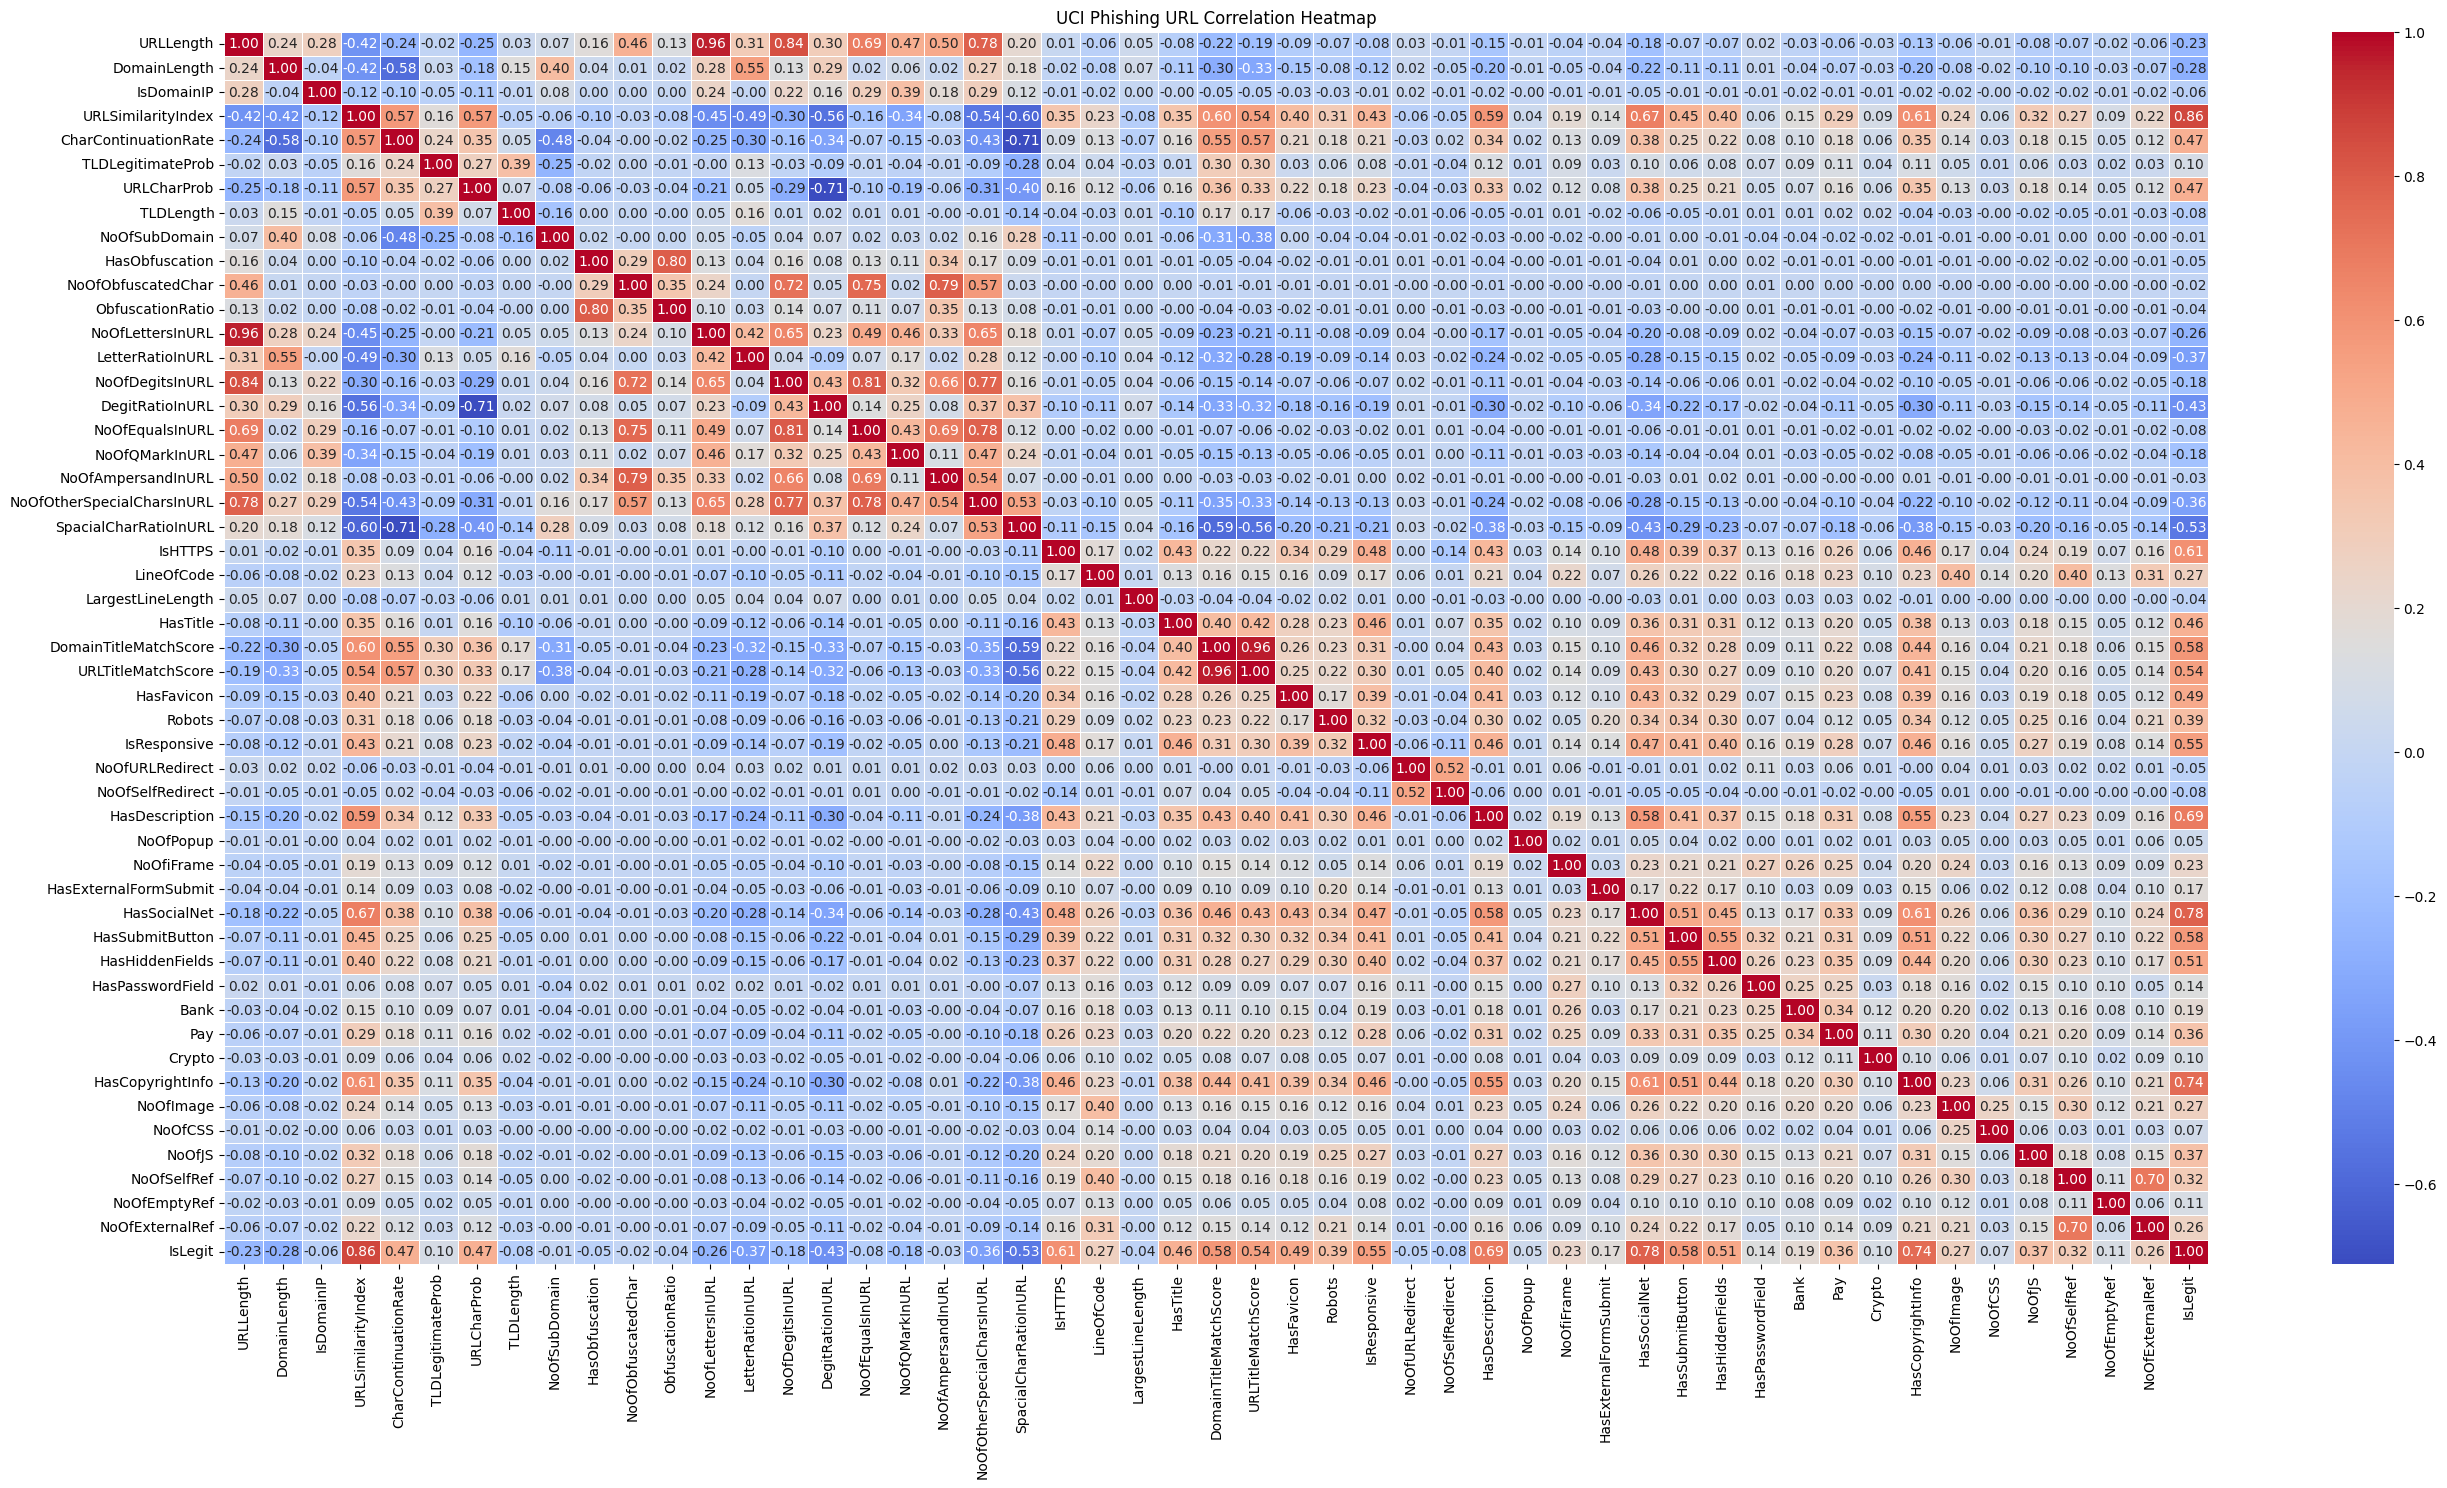

In [29]:
show_corr_matrix(df, "./outputs/uci_phishing_url_corr_matrix.png")

In [30]:
X_train, X_test, y_train, y_test = get_training_test_data(X, y)
logistic_regression_model_training(X_train, X_test, y_train, y_test)

working on i
working on i


KeyboardInterrupt: 

# Train the models in the pipeline

In [31]:
KNN_pipeline.fit(X_train, y_train)
DT_pipeline.fit(X_train, y_train)
random_forest_pipeline.fit(X_train, y_train)
SGD_pipeline.fit(X_train, y_train)
linearSVM_pipeline.fit(X_train, y_train)

/home/otter/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,steps,"[('nonetype', ...), ('linearsvr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,epsilon,0.0
,tol,0.0001
,C,1.0
,loss,'epsilon_insensitive'
,fit_intercept,True
,intercept_scaling,1.0
,dual,'auto'


## Check the pipeline

In [32]:
evaluate_model(DT_pipeline, X_test, y_test)

Split ratio is: 
param: DecisionTreeClassifier() -- Accuracy: 1.0 / Precision: 1.0 / Recall: 1.0 / Prediction Latency: 48.1ms
Confusion matrix is:
[[25276     0]
 [    0 33673]]
_____________________________________________________


In [33]:
evaluate_model(KNN_pipeline, X_test, y_test)

Split ratio is: 
param: KNeighborsClassifier() -- Accuracy: 0.997 / Precision: 0.997 / Recall: 0.999 / Prediction Latency: 53525.1ms
Confusion matrix is:
[[25132   144]
 [   31 33642]]
_____________________________________________________


In [34]:
evaluate_model(random_forest_pipeline, X_test, y_test)

Split ratio is: 
param: RandomForestClassifier() -- Accuracy: 1.0 / Precision: 1.0 / Recall: 1.0 / Prediction Latency: 440.9ms
Confusion matrix is:
[[25276     0]
 [    0 33673]]
_____________________________________________________


In [35]:
evaluate_model(SGD_pipeline, X_test, y_test)

Split ratio is: 
param: SGDClassifier() -- Accuracy: 0.991 / Precision: 0.991 / Recall: 0.997 / Prediction Latency: 19.2ms
Confusion matrix is:
[[24862   414]
 [  108 33565]]
_____________________________________________________


In [36]:
# evaluate_model(linearSVM_pipeline, X_test, y_test)

ValueError: Classification metrics can't handle a mix of binary and continuous targets